In [ ]:
# Install any missing libraries (usually pre-installed in Colab)
!pip install seaborn scikit-learn pandas numpy matplotlib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score, accuracy_score
)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Machine Learning/titanic.csv')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
# Load Titanic dataset directly from seaborn (no download needed!)
import seaborn as sns
df = sns.load_dataset('titanic')


print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (891, 15)

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Class Distribution (Survived) ===")
print(df['survived'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

=== Missing Values ===
survived         0
pclass         

In [ ]:
# ── Step 1: Select useful columns ──────────────────────────────────────────
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]

# ── Step 2: Handle missing values ──────────────────────────────────────────
df['age'].fillna(df['age'].median(), inplace=True)       # fill age with median
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)  # fill with most common
df.dropna(inplace=True)  # drop any remaining nulls

print("Missing values after cleaning:")
print(df.isnull().sum())

# ── Step 3: Encode categorical features ────────────────────────────────────
df['sex'] = df['sex'].map({'male': 0, 'female': 1})          # label encode
embarked_dummies = pd.get_dummies(df['embarked'], prefix='embarked', drop_first=True)
df = pd.concat([df.drop('embarked', axis=1), embarked_dummies], axis=1)

print("\nColumns after encoding:", df.columns.tolist())

# ── Step 4: Separate features (X) and target (y) ───────────────────────────
X = df.drop('survived', axis=1)
y = df['survived']

# ── Step 5: Split into Train / Validation / Test (60 / 20 / 20) ────────────
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# ── Step 6: Standardize numerical features ──────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit on train only!
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("\nPreprocessing complete!")

Missing values after cleaning:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

Columns after encoding: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']

Train: 534 | Val: 178 | Test: 179

Preprocessing complete!


/tmp/ipykernel_4723/3644741290.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)       # fill age with median
/tmp/ipykernel_4723/3644741290.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].met

In [ ]:
# Create and train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"\nValidation Accuracy: {model.score(X_val, y_val):.4f}")

Model trained successfully!

Validation Accuracy: 0.7640


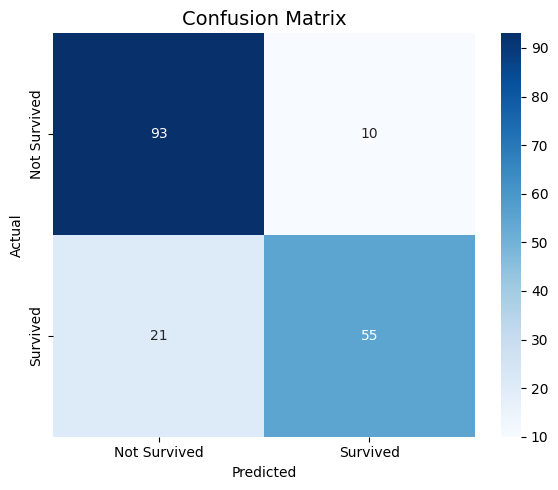

In [ ]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)  # saves for download
plt.show()

In [ ]:
print("=" * 50)
print("       EVALUATION METRICS (Test Set)")
print("=" * 50)

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print(f"\n  Accuracy : {acc:.4f}")
print(f"  AUC Score: {auc:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

       EVALUATION METRICS (Test Set)

  Accuracy : 0.8268
  AUC Score: 0.8878

Detailed Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.90      0.86       103
    Survived       0.85      0.72      0.78        76

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.82       179



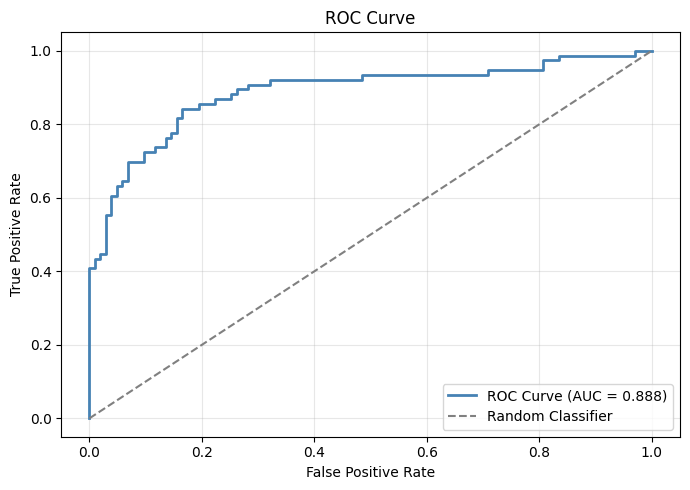

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [ ]:
# Show 10 sample predictions with probability scores
y_prob_all = model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    'Actual':      y_test.values[:10],
    'Predicted':   y_pred[:10],
    'Probability': y_prob_all[:10].round(3)
})

results['Actual Label']    = results['Actual'].map({0: 'Not Survived', 1: 'Survived'})
results['Predicted Label'] = results['Predicted'].map({0: 'Not Survived', 1: 'Survived'})
results['Correct?']        = results['Actual'] == results['Predicted']

print("Sample Predictions (first 10 test passengers):\n")
print(results[['Actual Label', 'Predicted Label', 'Probability', 'Correct?']].to_string(index=False))

Sample Predictions (first 10 test passengers):

Actual Label Predicted Label  Probability  Correct?
Not Survived    Not Survived        0.095      True
Not Survived    Not Survived        0.098      True
Not Survived    Not Survived        0.110      True
    Survived        Survived        0.512      True
Not Survived    Not Survived        0.195      True
Not Survived    Not Survived        0.425      True
    Survived        Survived        0.933      True
    Survived        Survived        0.934      True
Not Survived    Not Survived        0.099      True
Not Survived    Not Survived        0.106      True
